In [2]:
pip install pymc

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# Hierarchical Bayesian state-space model for NEON-style
# five-plot hourly soil CO2 efflux data
#
# Required packages:
#   pip install pandas numpy pymc arviz matplotlib
# ============================================================

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------
# This version is pre-configured for NEON-style all-position hourly CSVs
# where:
#   - TIME_COL is the timestamp
#   - PLOT_COL is the repeated chamber / horizontal-position identifier
#   - FLUX_COL is the flux series to model
# The model uses startDateTime for time ordering, so it naturally handles
# year-long or multi-year files without needing a separate year column.

site_name = "YELL" # define site_name
year = 2023
CSV_FILE = f"data/{site_name}_{year}_hourly_gC_allpos.csv"

TIME_COL = "startDateTime"
PLOT_COL = "horizontalPosition"
FLUX_COL = "flux_gC"

MIN_PLOTS_PER_HOUR_FOR_PLOTTING = 1   # used only for plotting/inspection
SUBSET_START = "2023-01-01"                   # e.g. "2020-04-01"
SUBSET_END = "2023-12-31"                     # e.g. "2020-06-30"
LOG_TRANSFORM = True                  # often useful for positive fluxes
RANDOM_SEED = 42


In [4]:
# ------------------------------------------------------------
# 2. READ AND PREPARE DATA
#    Robust to NaNs / NA strings / missing plot-hours; treats PLOT_COL as repeated plot/chamber observations
# ------------------------------------------------------------
df = pd.read_csv(
    CSV_FILE,
    na_values=["NaN", "nan", "NA", "N/A", "", "null", "NULL", "None"],
    keep_default_na=True,
)

# Parse/clean core columns
# Time strings that cannot be parsed become NaT
# Flux values that cannot be parsed become NaN
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")
df[FLUX_COL] = pd.to_numeric(df[FLUX_COL], errors="coerce")
df[FLUX_COL] = df[FLUX_COL].replace([np.inf, -np.inf], np.nan)

# Keep only needed columns
df = df[[TIME_COL, PLOT_COL, FLUX_COL]].copy()

# Remove rows with unusable time or missing plot ID
# Keep NaN flux values for now so we can preserve missing plot-hours
df = df.dropna(subset=[TIME_COL, PLOT_COL])

# Optional time subset
if SUBSET_START is not None:
    df = df[df[TIME_COL] >= pd.Timestamp(SUBSET_START, tz="UTC")]
if SUBSET_END is not None:
    # include the full end day if a date string is supplied
    end_ts = pd.Timestamp(SUBSET_END, tz="UTC")
    if end_ts.hour == 0 and end_ts.minute == 0 and end_ts.second == 0:
        end_ts = end_ts + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    df = df[df[TIME_COL] <= end_ts]

# If log-transforming, non-positive flux cannot be used as observations
# but we still treat them as missing rather than crashing
if LOG_TRANSFORM:
    df.loc[df[FLUX_COL] <= 0, FLUX_COL] = np.nan

# Round to hour to ensure consistent hourly timestamps
df["datetime_hour"] = df[TIME_COL].dt.floor("h")

# If there are duplicate measurements within the same plot-hour,
# average them. mean() skips NaNs by default; groups with all-NaN remain NaN.
df_hourly = (
    df.groupby(["datetime_hour", PLOT_COL], as_index=False)[FLUX_COL]
      .mean()
)

# Sort for stable downstream behavior
df_hourly = df_hourly.sort_values(["datetime_hour", PLOT_COL]).reset_index(drop=True)

# Build a COMPLETE hourly grid so missing hours / plot-hours remain in the model timeline
all_plots = sorted(df_hourly[PLOT_COL].dropna().unique())
if len(all_plots) == 0:
    raise ValueError("No valid plot IDs found after cleaning the data.")

if SUBSET_START is not None:
    time_start = pd.Timestamp(SUBSET_START, tz="UTC").floor("h")
else:
    time_start = df_hourly["datetime_hour"].min()

if SUBSET_END is not None:
    time_end = pd.Timestamp(SUBSET_END, tz="UTC").floor("h")
else:
    time_end = df_hourly["datetime_hour"].max()

all_times = pd.date_range(start=time_start, end=time_end, freq="h", tz="UTC")
if len(all_times) == 0:
    raise ValueError("No hourly timestamps remain after applying the requested subset.")

full_index = pd.MultiIndex.from_product(
    [all_times, all_plots], names=["datetime_hour", PLOT_COL]
)

df_full = (
    df_hourly.set_index(["datetime_hour", PLOT_COL])
             .reindex(full_index)
             .reset_index()
)

# Create hour-of-day and integer indices on the FULL grid
time_to_idx = {t: i for i, t in enumerate(all_times)}
plot_to_idx = {p: i for i, p in enumerate(all_plots)}

df_full["hour_of_day"] = df_full["datetime_hour"].dt.hour
df_full["time_idx"] = df_full["datetime_hour"].map(time_to_idx)
df_full["plot_idx"] = df_full[PLOT_COL].map(plot_to_idx)

n_time = len(all_times)
n_plot = len(all_plots)

print(f"Number of hourly time steps in full grid: {n_time}")
print(f"Number of plots: {n_plot}")
print(f"Plots found: {all_plots}")
print(f"Total plot-hour rows in full grid: {len(df_full)}")
print(f"Missing flux rows in full grid: {df_full[FLUX_COL].isna().sum()}")

# Response variable on the FULL grid
if LOG_TRANSFORM:
    df_full["y"] = np.log(df_full[FLUX_COL])
else:
    df_full["y"] = df_full[FLUX_COL]

# Only pass NON-MISSING observations into PyMC.
# This keeps the full time axis intact while allowing arbitrary NaNs in the CSV.
obs_mask = df_full["y"].notna().values
if obs_mask.sum() == 0:
    raise ValueError("No non-missing observations remain for model fitting after cleaning/log-transform rules.")

# df_obs is the observed subset used by the likelihood
df_obs = df_full.loc[obs_mask].copy().reset_index(drop=True)

# Observed arrays
y_obs = df_obs["y"].values
time_idx_obs = df_obs["time_idx"].astype(int).values
plot_idx_obs = df_obs["plot_idx"].astype(int).values
hour_idx_obs = df_obs["hour_of_day"].astype(int).values

print(f"Rows used in likelihood: {len(df_obs)}")
print(f"Rows skipped as missing: {len(df_full) - len(df_obs)}")


Number of hourly time steps in full grid: 8737
Number of plots: 5
Plots found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Total plot-hour rows in full grid: 43685
Missing flux rows in full grid: 37602
Rows used in likelihood: 6083
Rows skipped as missing: 37602


In [5]:
# ------------------------------------------------------------
# 3. BUILD HIERARCHICAL BAYESIAN STATE-SPACE MODEL
#   Alternative AR model AR(1) latent process + annual seasonal term
# ------------------------------------------------------------

coords = {
    "time": np.arange(n_time),
    "plot": all_plots,
    "hour_of_day": np.arange(24),
    "obs_id": np.arange(len(df_obs)),
}

# Build time-based seasonal covariates on the full hourly grid
# One cycle per year on the model time axis
t_full = np.arange(n_time)
annual_period = 24.0 * 365.0

annual_sin_1 = np.sin(2 * np.pi * t_full / annual_period)
annual_cos_1 = np.cos(2 * np.pi * t_full / annual_period)

# Optional second harmonic for a little more seasonal flexibility
annual_sin_2 = np.sin(4 * np.pi * t_full / annual_period)
annual_cos_2 = np.cos(4 * np.pi * t_full / annual_period)

with pm.Model(coords=coords) as model:

    # --------------------------------------------------------
    # 3a. Latent site process: annual seasonal mean + AR(1) residual
    # --------------------------------------------------------
    # Overall mean level on the modeled scale
    beta0 = pm.Normal("beta0", mu=np.nanmean(y_obs), sigma=2.0)

    # Annual seasonal harmonics
    beta_sin_1 = pm.Normal("beta_sin_1", mu=0.0, sigma=1.0)
    beta_cos_1 = pm.Normal("beta_cos_1", mu=0.0, sigma=1.0)
    beta_sin_2 = pm.Normal("beta_sin_2", mu=0.0, sigma=0.5)
    beta_cos_2 = pm.Normal("beta_cos_2", mu=0.0, sigma=0.5)

    seasonal_mean = pm.Deterministic(
        "seasonal_mean",
        beta0
        + beta_sin_1 * annual_sin_1
        + beta_cos_1 * annual_cos_1
        + beta_sin_2 * annual_sin_2
        + beta_cos_2 * annual_cos_2,
        dims="time",
    )

    # AR(1) persistence coefficient
    # Constrain to (-1, 1) for stability
    rho = pm.Uniform("rho", lower=-0.99, upper=0.99)

    # Innovation SD of AR(1)
    sigma_proc = pm.HalfNormal("sigma_proc", sigma=0.2)

    # AR(1) residual around zero
    # pm.AR expects rho and sigma; with a scalar rho this is AR(1)
    mu_ar_dev = pm.AR(
        "mu_ar_dev",
        rho=rho,
        sigma=sigma_proc,
        constant=False,
        init_dist=pm.Normal.dist(0.0, sigma=0.5),
        dims="time",
    )

    # Final latent site-level state
    # Keep the name mu_rw so the rest of your downstream code still works
    mu_rw = pm.Deterministic(
        "mu_rw",
        seasonal_mean + mu_ar_dev,
        dims="time",
    )

    # --------------------------------------------------------
    # 3b. Plot-specific offsets
    # --------------------------------------------------------
    sigma_plot = pm.HalfNormal("sigma_plot", sigma=0.5)
    plot_offset_raw = pm.Normal("plot_offset_raw", mu=0.0, sigma=1.0, dims="plot")

    plot_offset = pm.Deterministic(
        "plot_offset",
        plot_offset_raw - pm.math.mean(plot_offset_raw),
        dims="plot",
    )

    # --------------------------------------------------------
    # 3c. Hour-of-day effect
    # --------------------------------------------------------
    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.3)
    hour_effect_raw = pm.Normal("hour_effect_raw", mu=0.0, sigma=1.0, dims="hour_of_day")

    hour_effect = pm.Deterministic(
        "hour_effect",
        sigma_hour * (hour_effect_raw - pm.math.mean(hour_effect_raw)),
        dims="hour_of_day",
    )

    # --------------------------------------------------------
    # 3d. Plot-specific observation error
    # --------------------------------------------------------
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5, dims="plot")

    # --------------------------------------------------------
    # 3e. Observation model
    # --------------------------------------------------------
    mu_obs = (
        mu_rw[time_idx_obs]
        + sigma_plot * plot_offset[plot_idx_obs]
        + hour_effect[hour_idx_obs]
    )

    y_like = pm.Normal(
        "y_like",
        mu=mu_obs,
        sigma=sigma_obs[plot_idx_obs],
        observed=y_obs,
        dims="obs_id",
    )

    # --------------------------------------------------------
    # 3f. Sample posterior
    # --------------------------------------------------------
    idata = pm.sample(
        draws=1000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        max_treedepth=15,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta_sin_1, beta_cos_1, beta_sin_2, beta_cos_2, rho, sigma_proc, mu_ar_dev, sigma_plot, plot_offset_raw, sigma_hour, hour_effect_raw, sigma_obs]


Output()

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━╺━━━━━━━   2088    0             0.001       32767        10.01 s/draws    5:48:42   3:31:31    
  ━━━━━━━━━━━━━━━━━╺━━━━━━━   2088    0             0.001       32767        10.01 s/draws    5:48:42   3:30:32    
  ━━━━━━━━━━━━━━━━━╺━━━━━━━   2071    0             0.001       32767        10.09 s/draws    5:48:42   3:33:20    
  ━━━━━━━━━━━━━━━━━╺━━━━━━━   2073    0             0.001       32767        10.09 s/draws    5:48:42   3:30:22

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 37495 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta0        -10.485  0.109 -10.682  -10.267      0.005    0.002   281.869   
beta_sin_1    -0.101  0.029  -0.154   -0.039      0.007    0.004    18.992   
beta_cos_1    -0.799  0.035  -0.858   -0.723      0.011    0.005    10.091   
beta_sin_2     0.040  0.033  -0.016    0.107      0.009    0.005    13.502   
beta_cos_2    -0.021  0.033  -0.070    0.049      0.013    0.007     7.287   
rho            0.981  0.003   0.976    0.985      0.000    0.000   325.258   
sigma_proc     0.032  0.001   0.031    0.034      0.000    0.000   279.642   
sigma_plot     0.432  0.170   0.187    0.761      0.003    0.003  2550.055   
sigma_hour     0.024  0.004   0.017    0.032      0.000    0.000   828.201   
sigma_obs[1]   0.461  0.004   0.453    0.469      0.000    0.000  6856.506   
sigma_obs[2]   0.400  0.308   0.000    0.951      0.005    0.006  2611.472   
sigma_obs[3]   0.088  0.001   0.086    0.090      0.000    0.000

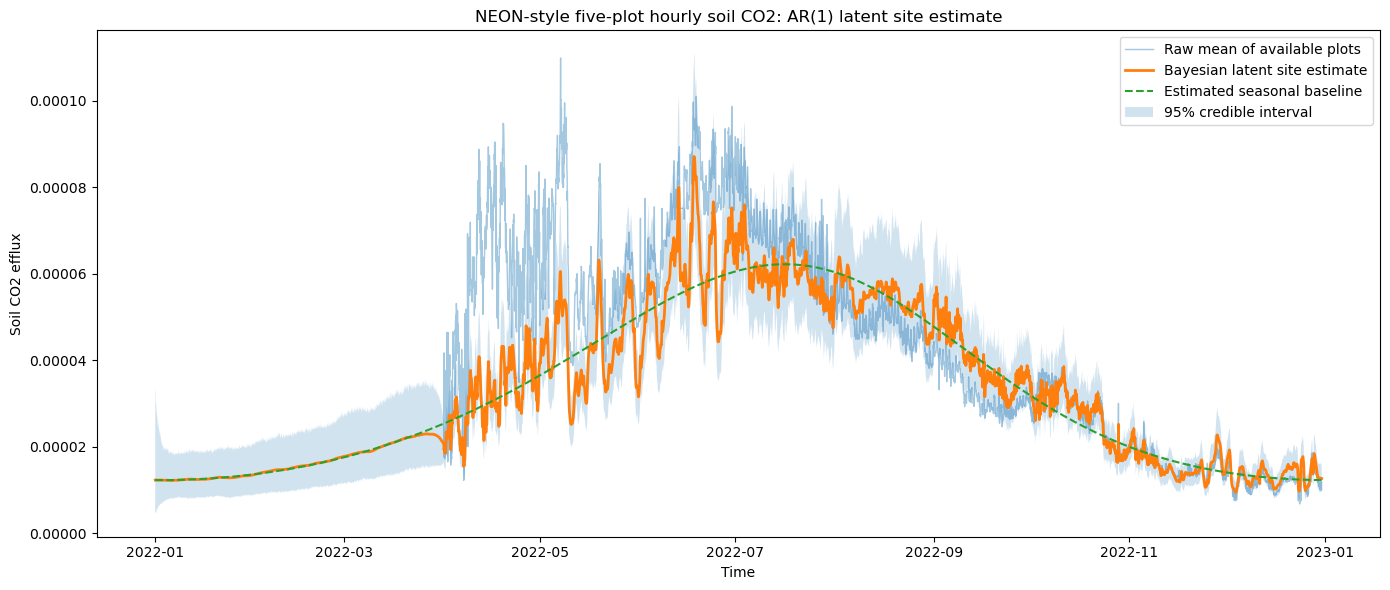

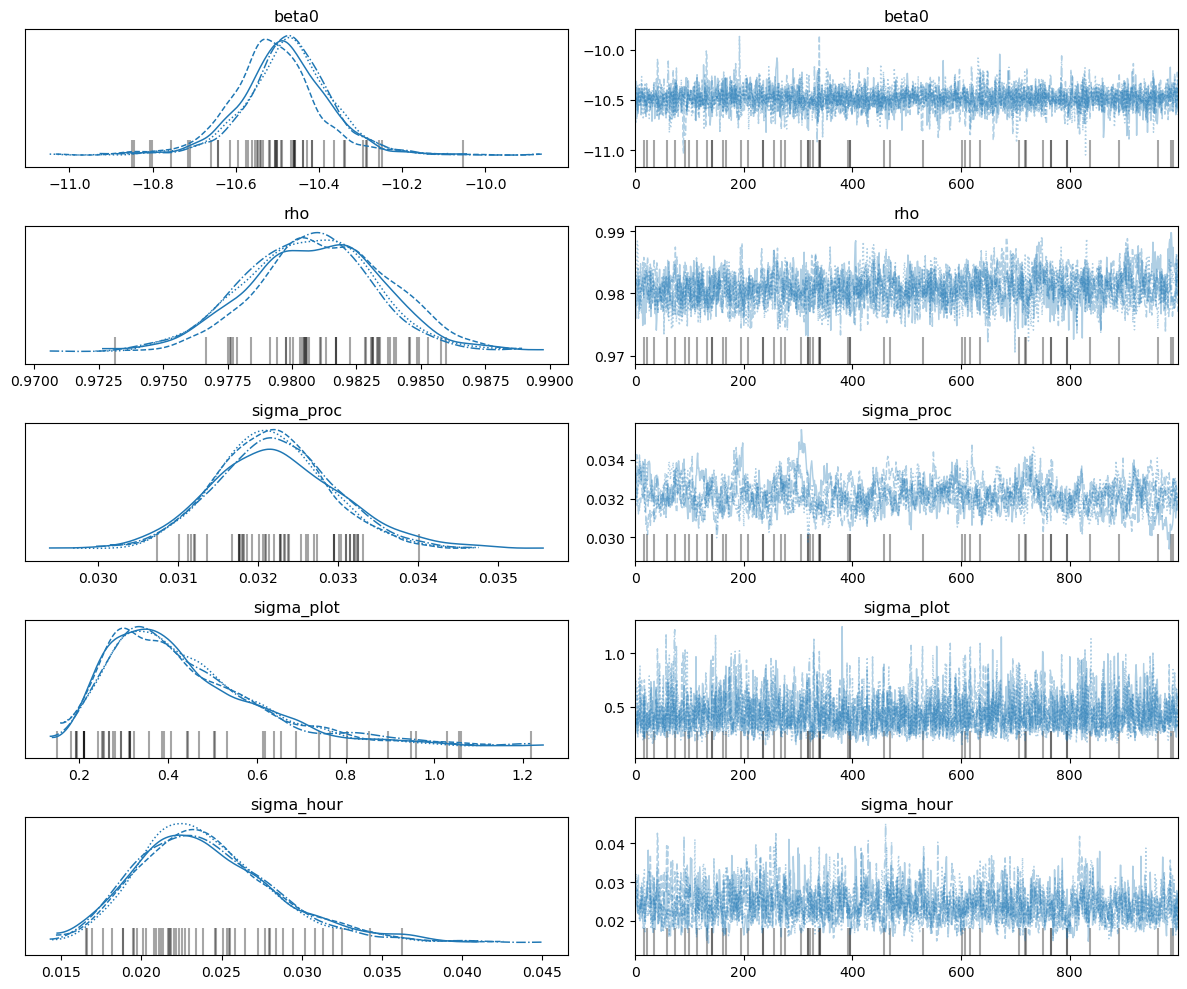

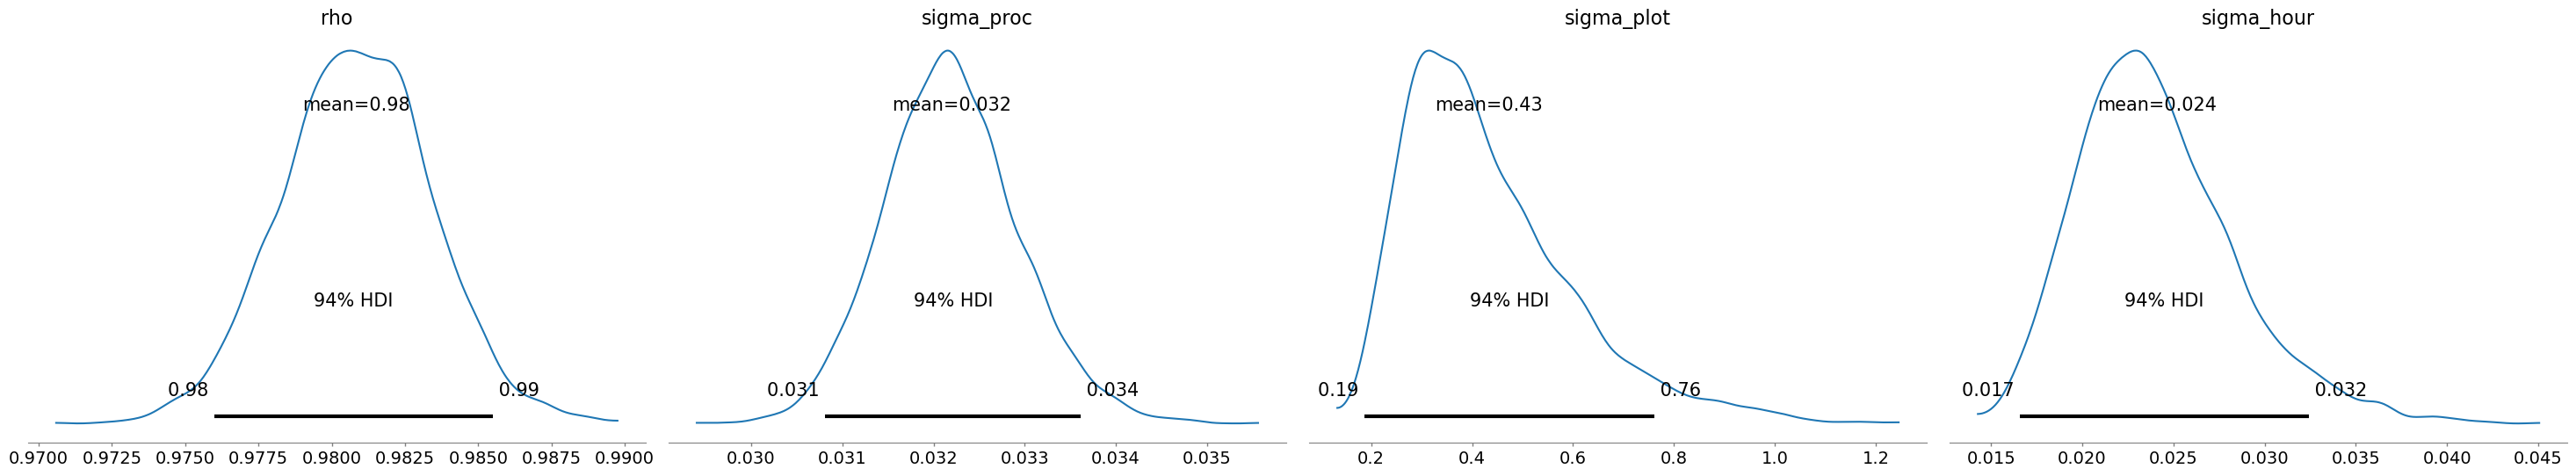

                mean     sd  ess_bulk  ess_tail  r_hat
beta0        -10.485  0.109   281.869  2647.791  1.016
rho            0.981  0.003   325.258   642.093  1.021
sigma_proc     0.032  0.001   279.642   439.049  1.015
sigma_plot     0.432  0.170  2550.055  2441.842  1.000
sigma_hour     0.024  0.004   828.201  2100.752  1.006
sigma_obs[1]   0.461  0.004  6856.506  2609.545  1.002
sigma_obs[2]   0.400  0.308  2611.472  1734.858  1.001
sigma_obs[3]   0.088  0.001  2837.499  2895.639  1.001
sigma_obs[4]   0.377  0.003  5996.151  2782.586  1.000
sigma_obs[5]   0.021  0.001   351.805   644.161  1.015
Saved:
 bayesian_site_hourly_soil_co2_estimate_AR1.csv
  bayesian_plot_offsets_AR1.csv
  bayesian_hour_effects_AR1.csv
  bayesian_scalar_parameters_AR1.csv


In [43]:
# ------------------------------------------------------------
# 4. POSTERIOR SUMMARIES
# ------------------------------------------------------------

print(az.summary(
    idata,
    var_names=[
        "beta0",
        "beta_sin_1", "beta_cos_1",
        "beta_sin_2", "beta_cos_2",
        "rho",
        "sigma_proc",
        "sigma_plot",
        "sigma_hour",
        "sigma_obs",
    ],
    round_to=3
))

# Posterior mean latent site state
mu_post = idata.posterior["mu_rw"].mean(dim=("chain", "draw")).values

# 95% HDI of latent site state
mu_hdi = az.hdi(idata.posterior["mu_rw"], hdi_prob=0.95).to_array().values[0]

# Posterior mean plot offsets
plot_offset_post = idata.posterior["plot_offset"].mean(dim=("chain", "draw")).values

# Posterior mean hour effects
hour_effect_post = idata.posterior["hour_effect"].mean(dim=("chain", "draw")).values

# Posterior mean seasonal baseline
seasonal_mean_post = idata.posterior["seasonal_mean"].mean(dim=("chain", "draw")).values

# Posterior summaries for key scalar parameters
rho_post = idata.posterior["rho"].mean(dim=("chain", "draw")).values.item()
sigma_proc_post = idata.posterior["sigma_proc"].mean(dim=("chain", "draw")).values.item()
sigma_plot_post = idata.posterior["sigma_plot"].mean(dim=("chain", "draw")).values.item()
sigma_hour_post = idata.posterior["sigma_hour"].mean(dim=("chain", "draw")).values.item()

print("\nPosterior mean rho:", round(rho_post, 4))
print("Posterior mean sigma_proc:", round(sigma_proc_post, 4))
print("Posterior mean sigma_plot:", round(sigma_plot_post, 4))
print("Posterior mean sigma_hour:", round(sigma_hour_post, 4))

# ------------------------------------------------------------
# 5. BACK-TRANSFORM TO ORIGINAL FLUX SCALE IF NEEDED
# ------------------------------------------------------------

site_result = pd.DataFrame({
    "datetime_hour": all_times,
    "mu_post": mu_post,
    "mu_low": mu_hdi[:, 0],
    "mu_high": mu_hdi[:, 1],
    "seasonal_mean_post": seasonal_mean_post,
})

if LOG_TRANSFORM:
    # Back-transform latent site estimate
    site_result["site_flux_est"] = np.exp(site_result["mu_post"])
    site_result["site_flux_low"] = np.exp(site_result["mu_low"])
    site_result["site_flux_high"] = np.exp(site_result["mu_high"])

    # Back-transform seasonal baseline
    site_result["seasonal_flux_est"] = np.exp(site_result["seasonal_mean_post"])
else:
    site_result["site_flux_est"] = site_result["mu_post"]
    site_result["site_flux_low"] = site_result["mu_low"]
    site_result["site_flux_high"] = site_result["mu_high"]
    site_result["seasonal_flux_est"] = site_result["seasonal_mean_post"]

# ------------------------------------------------------------
# 6. SIMPLE OBSERVED HOURLY MEAN FOR COMPARISON
# ------------------------------------------------------------

obs_hourly = (
    df_full.groupby("datetime_hour")
      .agg(
          obs_mean=(FLUX_COL, "mean"),
          n_plot=(FLUX_COL, "count"),
          obs_sd=(FLUX_COL, "std"),
      )
      .reset_index()
)

plot_df = site_result.merge(obs_hourly, on="datetime_hour", how="left")

# ------------------------------------------------------------
# 7. PLOT RESULTS
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

# Raw observed mean
plt.plot(
    plot_df["datetime_hour"],
    plot_df["obs_mean"],
    alpha=0.4,
    linewidth=1.0,
    label="Raw mean of available plots"
)

# Bayesian latent site estimate
plt.plot(
    plot_df["datetime_hour"],
    plot_df["site_flux_est"],
    linewidth=2,
    label="Bayesian latent site estimate"
)

# Optional: smooth seasonal baseline
plt.plot(
    plot_df["datetime_hour"],
    plot_df["seasonal_flux_est"],
    linewidth=1.5,
    linestyle="--",
    label="Estimated seasonal baseline"
)

# 95% credible interval
plt.fill_between(
    plot_df["datetime_hour"],
    plot_df["site_flux_low"],
    plot_df["site_flux_high"],
    alpha=0.2,
    label="95% credible interval"
)

plt.xlabel("Time")
plt.ylabel("Soil CO2 efflux")
plt.title("NEON-style five-plot hourly soil CO2: AR(1) latent site estimate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{site_name}_{year}_soil_co2_efflux.png", dpi=300, bbox_inches="tight")
plt.show()



# ------------------------------------------------------------
# 8. DIAGNOSTIC PLOTS
# ------------------------------------------------------------

# Trace plots
az.plot_trace(
    idata,
    var_names=[
        "beta0",
        "rho",
        "sigma_proc",
        "sigma_plot",
        "sigma_hour"
    ]
)
plt.tight_layout()
plt.savefig(f"{site_name}_{year}_trace_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# Posterior density plots
az.plot_posterior(
    idata,
    var_names=[
        "rho",
        "sigma_proc",
        "sigma_plot",
        "sigma_hour"
    ]
)
plt.tight_layout()
plt.savefig(f"{site_name}_{year}_posterior_density.png", dpi=300, bbox_inches="tight")
plt.show()


# Optional: summary diagnostics table
summary_df = az.summary(
    idata,
    var_names=[
        "beta0",
        "rho",
        "sigma_proc",
        "sigma_plot",
        "sigma_hour",
        "sigma_obs"
    ],
    round_to=3
)

print(summary_df[["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]])

# ------------------------------------------------------------
# 9. SAVE OUTPUTS
# ------------------------------------------------------------

# Save site hourly estimate
site_result[[
    "datetime_hour",
    "site_flux_est",
    "site_flux_low",
    "site_flux_high",
    "seasonal_flux_est"
]].to_csv(f"{site_name}_{year}_bayesian_site_hourly_soil_co2_estimate_AR1.csv", index=False)

# Save plot offsets
plot_offset_table = pd.DataFrame({
    "plotID": all_plots,
    "posterior_plot_offset": plot_offset_post
})
plot_offset_table.to_csv(f"{site_name}_{year}_bayesian_plot_offsets_AR1.csv", index=False)

# Save hour-of-day effects
hour_effect_table = pd.DataFrame({
    "hour_of_day": np.arange(24),
    "posterior_hour_effect": hour_effect_post
})
hour_effect_table.to_csv(f"{site_name}_{year}_bayesian_hour_effects_AR1.csv", index=False)

# Save scalar posterior summary
scalar_summary = pd.DataFrame({
    "parameter": ["rho", "sigma_proc", "sigma_plot", "sigma_hour"],
    "posterior_mean": [rho_post, sigma_proc_post, sigma_plot_post, sigma_hour_post]
})

#scalar_summary.to_csv("bayesian_scalar_parameters_AR1.csv", index=False)
scalar_summary.to_csv(
    f"{site_name}_{year}_bayesian_scalar_parameters_AR1.csv",index=False)

print("Saved:")
print(" bayesian_site_hourly_soil_co2_estimate_AR1.csv")
print("  bayesian_plot_offsets_AR1.csv")
print("  bayesian_hour_effects_AR1.csv")
print("  bayesian_scalar_parameters_AR1.csv")